In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
sales = pd.read_csv('/content/pizza_sales (1).csv')

## Data Preparation

Let's first prepare the data. This involves:
1.  Converting `order_date` to a datetime object.
2.  Converting `order_time` to a time object.
3.  Combining `order_date` and `order_time` into a single `order_datetime` column.
4.  Calculating the `revenue` for each item by multiplying `quantity` and `price`.

In [9]:
# Convert 'order_date' to datetime objects
sales['order_date'] = pd.to_datetime(sales['order_date'], format='%d/%m/%Y')

# Convert 'order_time' to datetime.time objects for easier manipulation
sales['order_time'] = pd.to_datetime(sales['order_time'], format='%H:%M:%S').dt.time

# Combine 'order_date' and 'order_time' into a single 'order_datetime' column
sales['order_datetime'] = sales.apply(lambda row: pd.to_datetime(str(row['order_date']).split(' ')[0] + ' ' + str(row['order_time'])), axis=1)

# Calculate revenue for each pizza
sales['revenue'] = sales['quantity'] * sales['unit_price']

# Display the first few rows with the new columns and their data types to verify
display(sales.head())
display(sales.info())

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name,order_datetime,revenue
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza,2015-01-01 11:38:36,13.25
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza,2015-01-01 11:57:40,16.00
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza,2015-01-01 11:57:40,18.50
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza,2015-01-01 11:57:40,20.75
4,5,2,mexicana_m,1,2015-01-01,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza,2015-01-01 11:57:40,16.00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   pizza_id           48620 non-null  int64         
 1   order_id           48620 non-null  int64         
 2   pizza_name_id      48620 non-null  object        
 3   quantity           48620 non-null  int64         
 4   order_date         48620 non-null  datetime64[ns]
 5   order_time         48620 non-null  object        
 6   unit_price         48620 non-null  float64       
 7   total_price        48620 non-null  float64       
 8   pizza_size         48620 non-null  object        
 9   pizza_category     48620 non-null  object        
 10  pizza_ingredients  48620 non-null  object        
 11  pizza_name         48620 non-null  object        
 12  order_datetime     48620 non-null  datetime64[ns]
 13  revenue            48620 non-null  float64       
dtypes: dat

None

In [25]:
sales.describe()

,pizza_id,order_id,quantity,order_date,unit_price,total_price,order_datetime,revenue
count,48620.000000,48620.000000,48620.000000,48620,48620.000000,48620.000000,48620,48620.000000
mean,24310.500000,10701.479761,1.019622,2015-06-29 11:03:43.611682560,16.494132,16.821474,2015-06-30 03:28:34.933833984,16.821474
min,1.000000,1.000000,1.000000,2015-01-01 00:00:00,9.750000,9.750000,2015-01-01 11:38:36,9.750000
25%,12155.750000,5337.000000,1.000000,2015-03-31 00:00:00,12.750000,12.750000,2015-03-31 15:34:31,12.750000
50%,24310.500000,10682.500000,1.000000,2015-06-28 00:00:00,16.500000,16.500000,2015-06-28 19:50:30,16.500000
75%,36465.250000,16100.000000,1.000000,2015-09-28 00:00:00,20.250000,20.500000,2015-09-28 18:39:55,20.500000
max,48620.000000,21350.000000,4.000000,2015-12-31 00:00:00,35.950000,83.000000,2015-12-31 23:02:05,83.000000
std,14035.529381,6180.119770,0.143077,NaN,3.621789,4.437398,NaN,4.437398


In [26]:
sales.isnull().sum()

,0
pizza_id,0
order_id,0
pizza_name_id,0
quantity,0
order_date,0
order_time,0
unit_price,0
total_price,0
pizza_size,0
pizza_category,0


## 1. Sales Performance & Revenue Analysis

Let's start by analyzing the overall sales performance and revenue trends.

### Total Revenue for 2015

First, we'll calculate the total revenue generated throughout the year 2015.

In [10]:
# Filter data for the year 2015
sales_2015 = sales[sales['order_date'].dt.year == 2015]

# Calculate total revenue for 2015
total_revenue_2015 = sales_2015['revenue'].sum()

print(f"Total Revenue generated in 2015: ${total_revenue_2015:,.2f}")

Total Revenue generated in 2015: $817,860.05


### Monthly Revenue Trends

Now, let's analyze how revenue changes month over month. This will help us identify any seasonal patterns or trends in sales.

/tmp/ipykernel_1534/2749245237.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_revenue.index, y=monthly_revenue.values, palette='viridis')


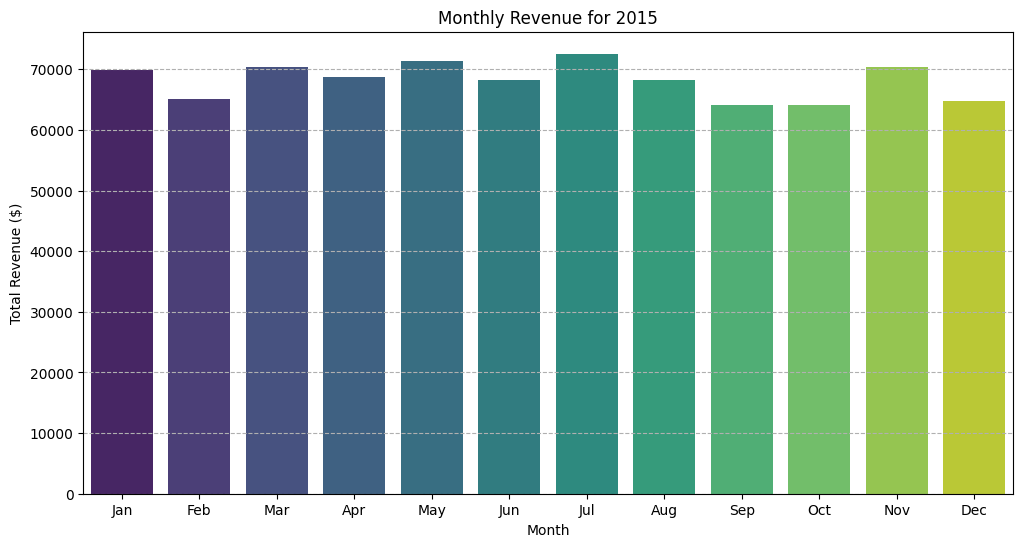

Monthly Revenue (2015):
order_date
Jan    69793.30
Feb    65159.60
Mar    70397.10
Apr    68736.80
May    71402.75
Jun    68230.20
Jul    72557.90
Aug    68278.25
Sep    64180.05
Oct    64027.60
Nov    70395.35
Dec    64701.15
Name: revenue, dtype: float64


In [11]:
# Group by month and sum the revenue
monthly_revenue = sales_2015.groupby(sales_2015['order_date'].dt.month)['revenue'].sum()

# Map month numbers to month names for better readability
month_names = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}
monthly_revenue = monthly_revenue.rename(index=month_names)

# Plotting the monthly revenue
plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_revenue.index, y=monthly_revenue.values, palette='viridis')
plt.title('Monthly Revenue for 2015')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.grid(axis='y', linestyle='--')
plt.show()

print("Monthly Revenue (2015):")
print(monthly_revenue)

### Daily & Hourly Sales Distribution

To optimize staffing and operations, understanding the daily and hourly sales distribution is crucial. We'll identify the peak sales days of the week and the busiest hours of the day.

/tmp/ipykernel_1534/3563303017.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=daily_revenue.index, y=daily_revenue.values, palette='plasma')


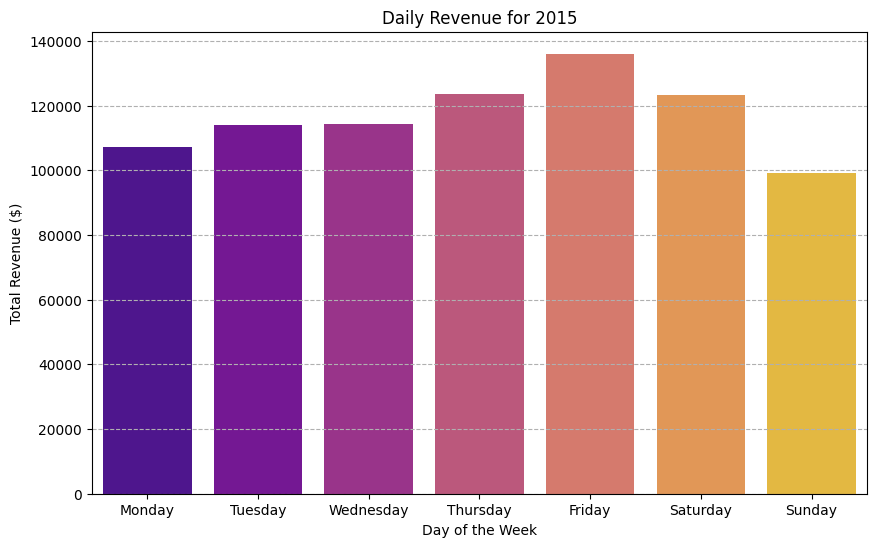

Daily Revenue (2015):
order_date
Monday       107329.55
Tuesday      114133.80
Wednesday    114408.40
Thursday     123528.50
Friday       136073.90
Saturday     123182.40
Sunday        99203.50
Name: revenue, dtype: float64


In [12]:
# Group by day of the week and sum the revenue
daily_revenue = sales_2015.groupby(sales_2015['order_date'].dt.day_name())['revenue'].sum().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

# Plotting the daily revenue
plt.figure(figsize=(10, 6))
sns.barplot(x=daily_revenue.index, y=daily_revenue.values, palette='plasma')
plt.title('Daily Revenue for 2015')
plt.xlabel('Day of the Week')
plt.ylabel('Total Revenue ($)')
plt.grid(axis='y', linestyle='--')
plt.show()

print("Daily Revenue (2015):")
print(daily_revenue)

/tmp/ipykernel_1534/1168330088.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x=hourly_revenue.index, y=hourly_revenue.values, marker='o', palette='viridis')


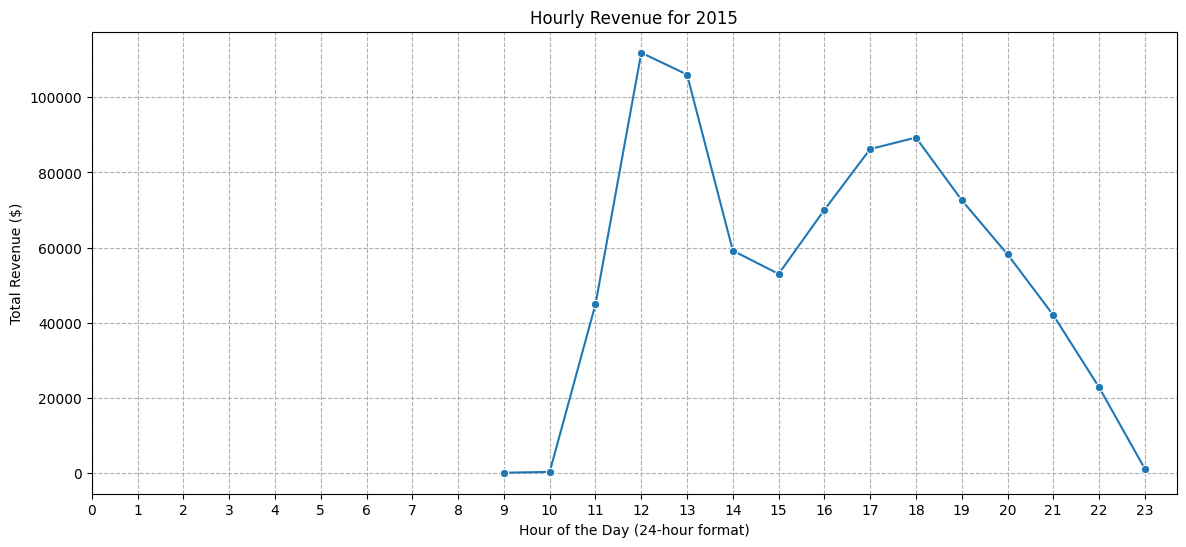

Hourly Revenue (2015):
order_datetime
9         83.00
10       303.65
11     44935.80
12    111877.90
13    106065.70
14     59201.40
15     52992.30
16     70055.40
17     86237.45
18     89296.85
19     72628.90
20     58215.40
21     42029.80
22     22815.15
23      1121.35
Name: revenue, dtype: float64


In [13]:
# Extract hour from 'order_datetime' and group by hour
hourly_revenue = sales_2015.groupby(sales_2015['order_datetime'].dt.hour)['revenue'].sum()

# Plotting the hourly revenue
plt.figure(figsize=(14, 6))
sns.lineplot(x=hourly_revenue.index, y=hourly_revenue.values, marker='o', palette='viridis')
plt.title('Hourly Revenue for 2015')
plt.xlabel('Hour of the Day (24-hour format)')
plt.ylabel('Total Revenue ($)')
plt.xticks(range(24)) # Ensure all hours are displayed
plt.grid(axis='both', linestyle='--')
plt.show()

print("Hourly Revenue (2015):")
print(hourly_revenue)

### Average Order Value (AOV)

Let's calculate the average revenue per order to understand the typical spending of customers.

In [14]:
# Calculate the total revenue per order
revenue_per_order = sales_2015.groupby('order_id')['revenue'].sum()

# Calculate the average order value (AOV)
average_order_value = revenue_per_order.mean()

print(f"Average Order Value (AOV) for 2015: ${average_order_value:,.2f}")

Average Order Value (AOV) for 2015: $38.31


---

## 2. Product Performance & Menu Optimization

Let's analyze the performance of individual pizza types and categories to optimize the menu.

### Top & Bottom-Selling Pizzas

We'll identify which pizza types are the most and least popular based on the total quantity sold.

Top 5 Selling Pizzas (by Quantity):
pizza_name
The Classic Deluxe Pizza      2453
The Barbecue Chicken Pizza    2432
The Hawaiian Pizza            2422
The Pepperoni Pizza           2418
The Thai Chicken Pizza        2371
Name: quantity, dtype: int64

Bottom 5 Selling Pizzas (by Quantity):
pizza_name
The Brie Carre Pizza         490
The Mediterranean Pizza      934
The Calabrese Pizza          937
The Spinach Supreme Pizza    950
The Soppressata Pizza        961
Name: quantity, dtype: int64


/tmp/ipykernel_1534/826467757.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_pizzas.index, y=top_5_pizzas.values, palette='Greens_d')


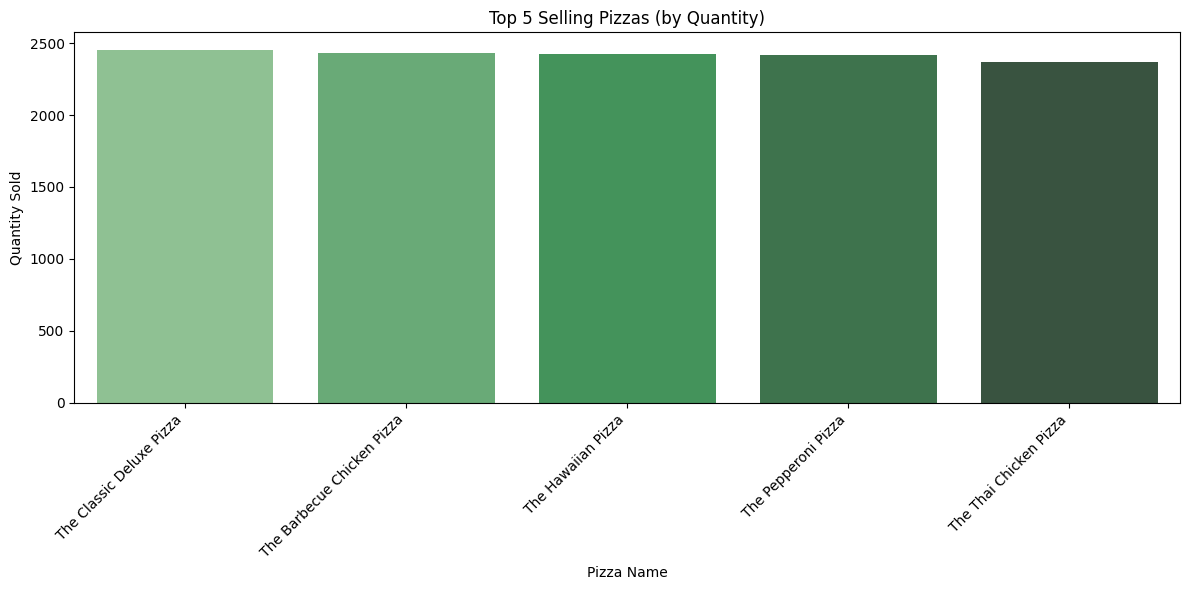

/tmp/ipykernel_1534/826467757.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_5_pizzas.index, y=bottom_5_pizzas.values, palette='Reds_d')


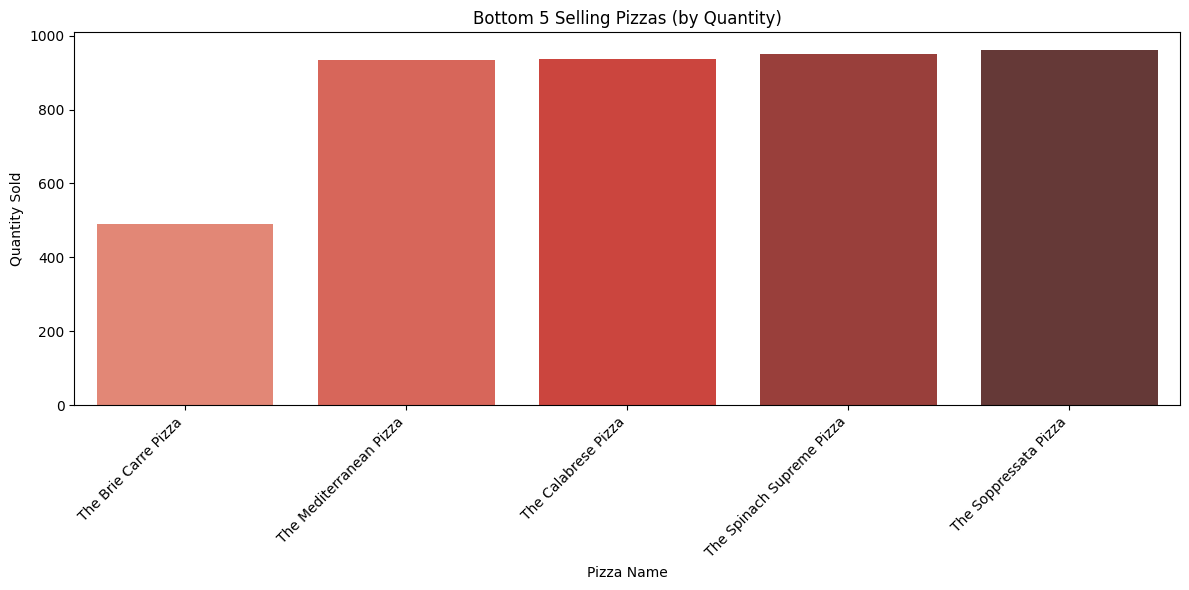

In [15]:
# Group by pizza name and sum the quantity sold
pizza_quantity = sales_2015.groupby('pizza_name')['quantity'].sum()

# Get top 5 selling pizzas
top_5_pizzas = pizza_quantity.nlargest(5)

# Get bottom 5 selling pizzas
bottom_5_pizzas = pizza_quantity.nsmallest(5)

print("Top 5 Selling Pizzas (by Quantity):")
print(top_5_pizzas)
print("\nBottom 5 Selling Pizzas (by Quantity):")
print(bottom_5_pizzas)

# Plotting top 5 pizzas
plt.figure(figsize=(12, 6))
sns.barplot(x=top_5_pizzas.index, y=top_5_pizzas.values, palette='Greens_d')
plt.title('Top 5 Selling Pizzas (by Quantity)')
plt.xlabel('Pizza Name')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plotting bottom 5 pizzas
plt.figure(figsize=(12, 6))
sns.barplot(x=bottom_5_pizzas.index, y=bottom_5_pizzas.values, palette='Reds_d')
plt.title('Bottom 5 Selling Pizzas (by Quantity)')
plt.xlabel('Pizza Name')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Revenue by Pizza Category

/tmp/ipykernel_1534/306146655.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_revenue.index, y=category_revenue.values, palette='coolwarm')


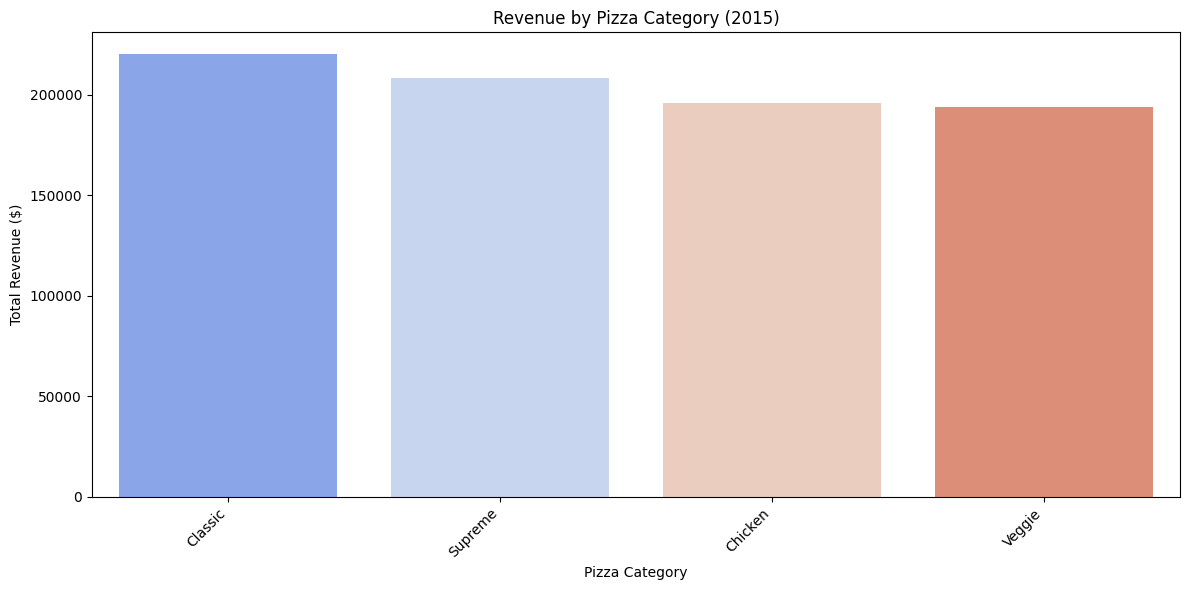

Revenue by Pizza Category (2015):
pizza_category
Classic    220053.10
Supreme    208197.00
Chicken    195919.50
Veggie     193690.45
Name: revenue, dtype: float64


In [16]:
# Group by pizza category and sum the revenue
category_revenue = sales_2015.groupby('pizza_category')['revenue'].sum().sort_values(ascending=False)

# Plotting the revenue by category
plt.figure(figsize=(12, 6))
sns.barplot(x=category_revenue.index, y=category_revenue.values, palette='coolwarm')
plt.title('Revenue by Pizza Category (2015)')
plt.xlabel('Pizza Category')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Revenue by Pizza Category (2015):")
print(category_revenue)

### Revenue by Pizza Size

/tmp/ipykernel_1534/3316608227.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=size_revenue.index, y=size_revenue.values, palette='magma')


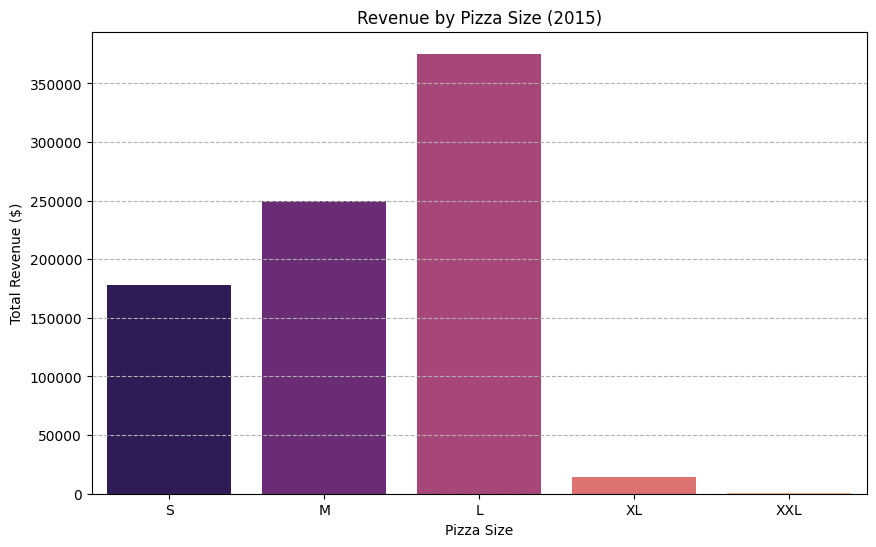

Revenue by Pizza Size (2015):
pizza_size
S      178076.50
M      249382.25
L      375318.70
XL      14076.00
XXL      1006.60
Name: revenue, dtype: float64


In [17]:
# Group by pizza size and sum the revenue
size_revenue = sales_2015.groupby('pizza_size')['revenue'].sum().reindex(['S', 'M', 'L', 'XL', 'XXL'])

# Plotting the revenue by size
plt.figure(figsize=(10, 6))
sns.barplot(x=size_revenue.index, y=size_revenue.values, palette='magma')
plt.title('Revenue by Pizza Size (2015)')
plt.xlabel('Pizza Size')
plt.ylabel('Total Revenue ($)')
plt.grid(axis='y', linestyle='--')
plt.show()

print("Revenue by Pizza Size (2015):")
print(size_revenue)

---

## 3. Customer & Order Behaviour

Let's delve into customer and order behavior to gain insights into typical purchasing patterns.

### Average Quantity per Order

We'll calculate the average number of pizzas ordered in a single transaction to understand typical order sizes.

In [18]:
# Calculate the total quantity per order
quantity_per_order = sales_2015.groupby('order_id')['quantity'].sum()

# Calculate the average quantity per order
average_quantity_per_order = quantity_per_order.mean()

print(f"Average Quantity per Order for 2015: {average_quantity_per_order:.2f} pizzas")

Average Quantity per Order for 2015: 2.32 pizzas


### Most Common Order Time

To further understand customer behavior and optimize staffing, let's identify the hours when most orders are placed.

The most common hour for orders in 2015 is 12:00 with 6543 orders.


/tmp/ipykernel_1534/942722892.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_orders.index, y=hourly_orders.values, palette='coolwarm')


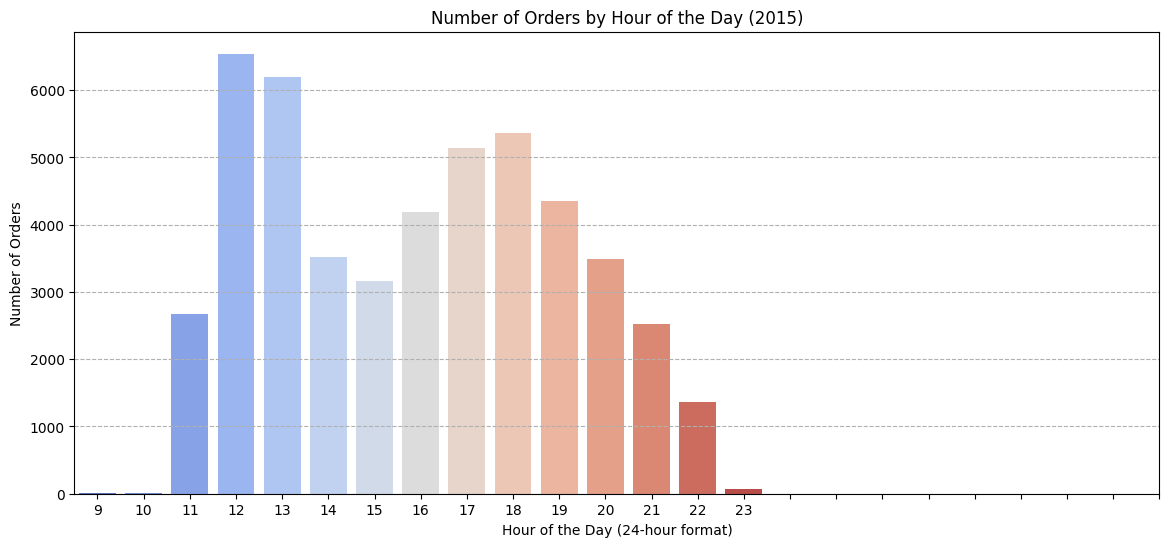

Hourly Order Count (2015):
order_datetime
9        4
10      17
11    2672
12    6543
13    6203
14    3521
15    3170
16    4185
17    5143
18    5359
19    4350
20    3487
21    2528
22    1370
23      68
dtype: int64


In [19]:
# Group by hour and count the number of orders
hourly_orders = sales_2015.groupby(sales_2015['order_datetime'].dt.hour).size()

# Get the hour with the maximum number of orders
most_common_order_hour = hourly_orders.idxmax()
max_orders = hourly_orders.max()

print(f"The most common hour for orders in 2015 is {most_common_order_hour}:00 with {max_orders} orders.")

# Plotting the hourly order count
plt.figure(figsize=(14, 6))
sns.barplot(x=hourly_orders.index, y=hourly_orders.values, palette='coolwarm')
plt.title('Number of Orders by Hour of the Day (2015)')
plt.xlabel('Hour of the Day (24-hour format)')
plt.ylabel('Number of Orders')
plt.xticks(range(24)) # Ensure all hours are displayed
plt.grid(axis='y', linestyle='--')
plt.show()

print("Hourly Order Count (2015):")
print(hourly_orders)

### Number of Orders by Day of the Week

To complement our daily revenue analysis, let's examine the number of orders placed on each day of the week.

/tmp/ipykernel_1534/2414632765.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=daily_orders_count.index, y=daily_orders_count.values, palette='viridis')


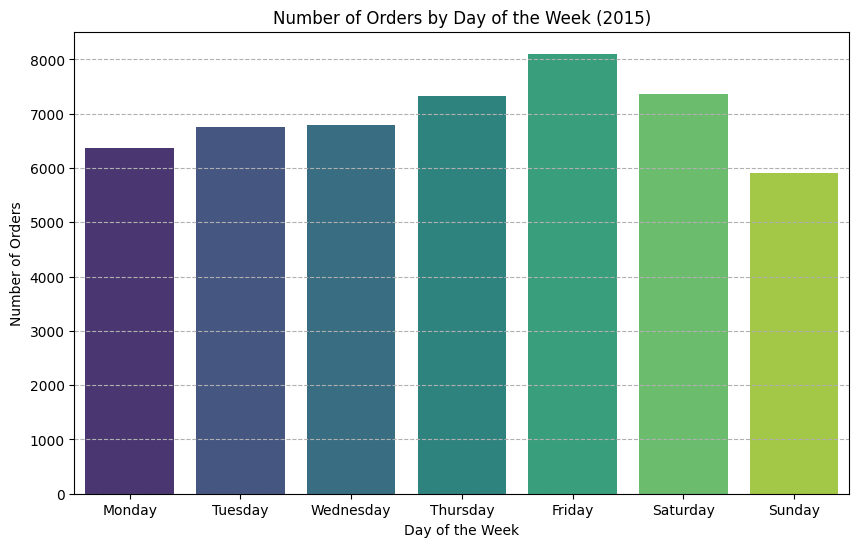

Number of Orders by Day of the Week (2015):
order_date
Monday       6369
Tuesday      6753
Wednesday    6797
Thursday     7323
Friday       8106
Saturday     7355
Sunday       5917
dtype: int64


In [20]:
# Group by day of the week and count the number of orders
daily_orders_count = sales_2015.groupby(sales_2015['order_date'].dt.day_name()).size().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

# Plotting the daily order count
plt.figure(figsize=(10, 6))
sns.barplot(x=daily_orders_count.index, y=daily_orders_count.values, palette='viridis')
plt.title('Number of Orders by Day of the Week (2015)')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Orders')
plt.grid(axis='y', linestyle='--')
plt.show()

print("Number of Orders by Day of the Week (2015):")
print(daily_orders_count)

---

## 4. Pricing & Discount Strategy

Let's analyze pricing strategies to understand customer responses to different price points and identify opportunities for optimization.

### Price Sensitivity Analysis

We'll analyze price sensitivity by comparing pizza prices to quantities sold to see how demand changes with price.

/tmp/ipykernel_1534/3569405855.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


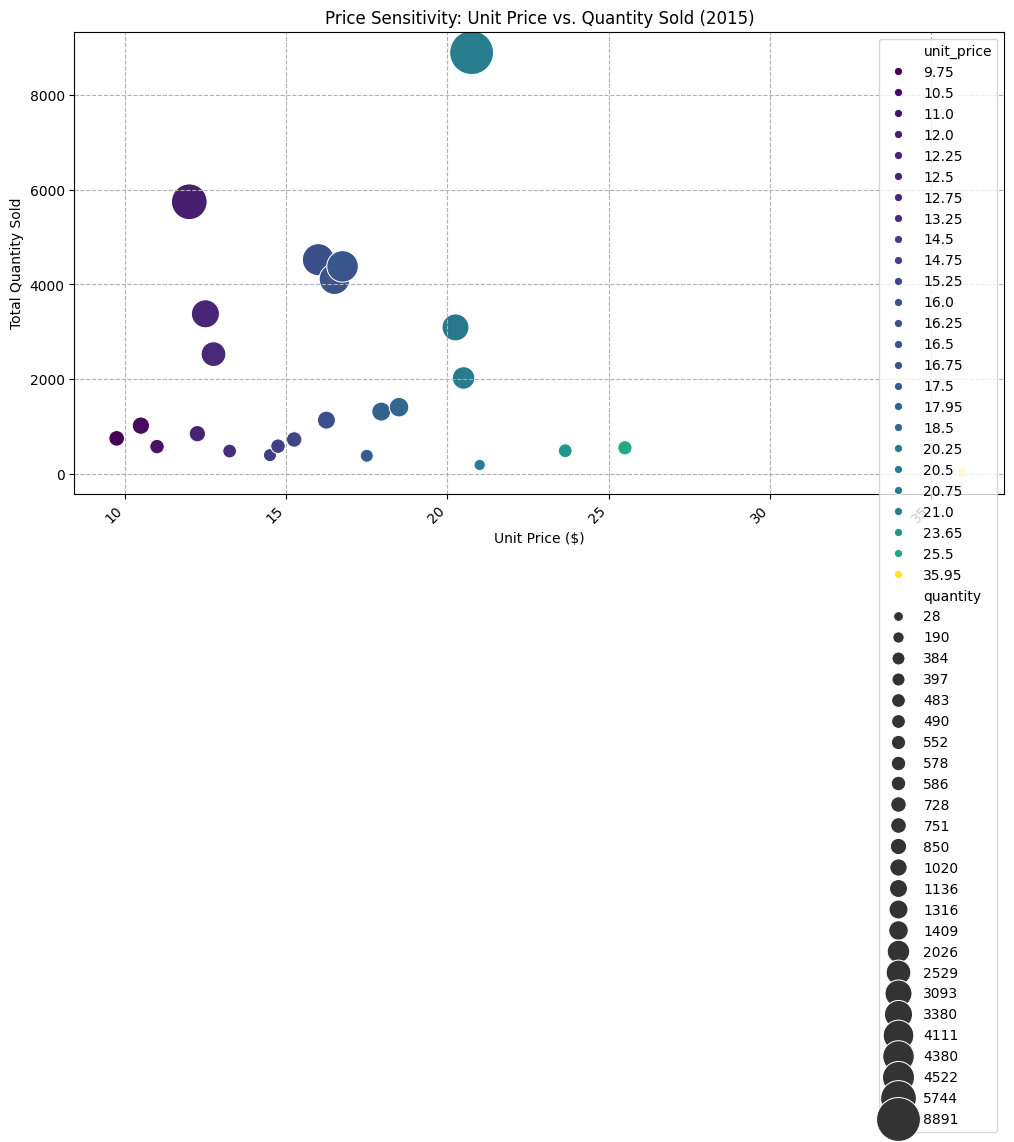

Price vs. Quantity Sold (first 10 rows):
   unit_price  quantity
0        9.75       751
1       10.50      1020
2       11.00       578
3       12.00      5744
4       12.25       850
5       12.50      3380
6       12.75      2529
7       13.25       483
8       14.50       397
9       14.75       586


In [21]:
# Group by unit price and sum the quantity sold
price_quantity = sales_2015.groupby('unit_price')['quantity'].sum().reset_index()

# Plotting price vs. quantity sold
plt.figure(figsize=(12, 6))
sns.scatterplot(x='unit_price', y='quantity', data=price_quantity, hue='unit_price', size='quantity', sizes=(50, 1000), palette='viridis', legend='full')
plt.title('Price Sensitivity: Unit Price vs. Quantity Sold (2015)')
plt.xlabel('Unit Price ($)')
plt.ylabel('Total Quantity Sold')
plt.grid(axis='both', linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Price vs. Quantity Sold (first 10 rows):")
print(price_quantity.head(10))

Based on the analysis of monthly quantity sold and monthly average price per pizza, here's what we can infer and some opportunities for seasonal promotions:

*   **Monthly Quantity Sold:** We observe a slight dip in the total quantity of pizzas sold during September, October, February, and December. Conversely, sales tend to be slightly higher in January, March, May, and July.
*   **Monthly Average Price Per Pizza:** The average price per pizza remains remarkably consistent throughout the year, hovering around $14. This suggests that customer preferences for higher or lower-priced pizzas do not significantly shift with the seasons.

**Opportunities for Seasonal Promotions:**

1.  **Boost Low-Demand Months:** Consider running targeted promotions during **September, October, February, and December**. These could include:
    *   **Discounted bundles:** Offer meal deals or family combos to increase order size.
    *   **Limited-time offers on popular pizzas:** Provide a small discount on best-selling pizzas to drive traffic.
    *   **Loyalty program incentives:** Double points or exclusive offers for loyalty members during these months.
    *   **Seasonal specialty pizzas:** Introduce unique, festive pizzas during holiday seasons (e.g., December) to create excitement and drive sales.

2.  **Maintain Momentum in High-Demand Months:** During months like **January, March, May, and July**, where quantity sold is already strong, focus on:
    *   **Upselling and Cross-selling:** Promote premium toppings, larger sizes, or complementary items (drinks, desserts) to increase the average order value.
    *   **Introduce new, higher-margin items:** Capitalize on existing high foot traffic by introducing new pizzas with better profit margins.
    *   **Partnerships or events:** Collaborate with local events or offer special catering packages to leverage existing demand.

Since the average price per pizza doesn't fluctuate much, a strategy focused on increasing the *quantity* of orders or the *value* of individual orders during specific months would be most effective.

### High-Value vs. Low-Value Orders

We'll categorize orders into high-value and low-value based on the median average order value and analyze their revenue contribution.

Median Revenue per Order: $32.50
Total Revenue from High-Value Orders ( > $32.50): $607,422.50 (74.27%)
Total Revenue from Low-Value Orders ( <= $32.50): $210,437.55 (25.73%)


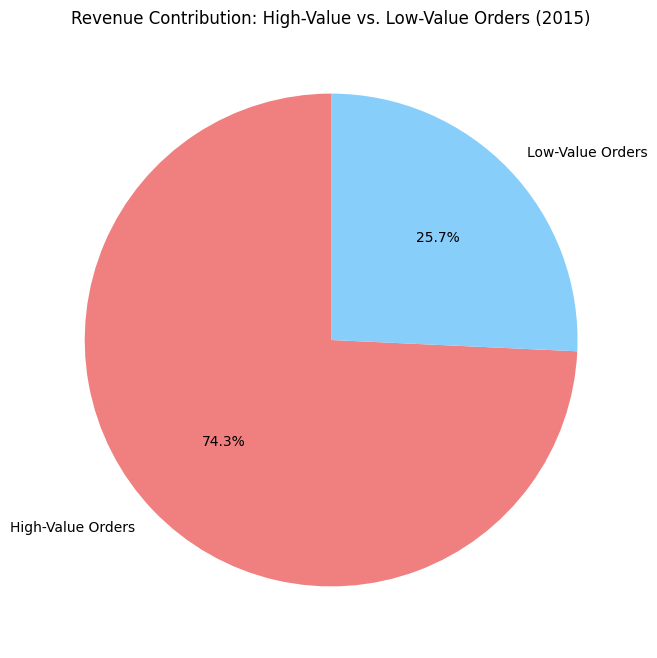

In [22]:
# Define a threshold for high-value orders. A common approach is using the median or a quartile.
median_revenue_per_order = revenue_per_order.median()

# Categorize orders as 'High-Value' or 'Low-Value'
high_value_orders = revenue_per_order[revenue_per_order > median_revenue_per_order]
low_value_orders = revenue_per_order[revenue_per_order <= median_revenue_per_order]

# Calculate total revenue for each category
total_revenue_high_value = high_value_orders.sum()
total_revenue_low_value = low_value_orders.sum()

# Calculate the overall total revenue from revenue_per_order to ensure consistency
overall_total_revenue = revenue_per_order.sum()

# Calculate the percentage contribution
percentage_high_value = (total_revenue_high_value / overall_total_revenue) * 100
percentage_low_value = (total_revenue_low_value / overall_total_revenue) * 100

print(f"Median Revenue per Order: ${median_revenue_per_order:,.2f}")
print(f"Total Revenue from High-Value Orders ( > ${median_revenue_per_order:,.2f}): ${total_revenue_high_value:,.2f} ({percentage_high_value:.2f}%)")
print(f"Total Revenue from Low-Value Orders ( <= ${median_revenue_per_order:,.2f}): ${total_revenue_low_value:,.2f} ({percentage_low_value:.2f}%)")

# Plotting the contribution
revenue_contribution = pd.Series({
    'High-Value Orders': total_revenue_high_value,
    'Low-Value Orders': total_revenue_low_value
})

plt.figure(figsize=(8, 8))
plt.pie(revenue_contribution, labels=revenue_contribution.index, autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'lightskyblue'])
plt.title('Revenue Contribution: High-Value vs. Low-Value Orders (2015)')
plt.ylabel('') # Hide the default 'y' label for pie chart
plt.show()

---

## 5. Ingredient & Inventory Optimization

Let's analyze ingredient usage to help with inventory management.

### Most Used Ingredients

We'll identify which ingredients are most frequently used across all pizzas to help with inventory planning.

Top 10 Most Used Ingredients (2015):
pizza_ingredients
Garlic               27422
Tomatoes             26601
Red Onions           19547
Red Peppers          16284
Mozzarella Cheese    10333
Pepperoni            10300
Spinach              10012
Mushrooms             9624
Chicken               8443
Capocollo             6572
Name: count, dtype: int64


/tmp/ipykernel_1534/3786472001.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_ingredients.index, y=top_10_ingredients.values, palette='Greens_r')


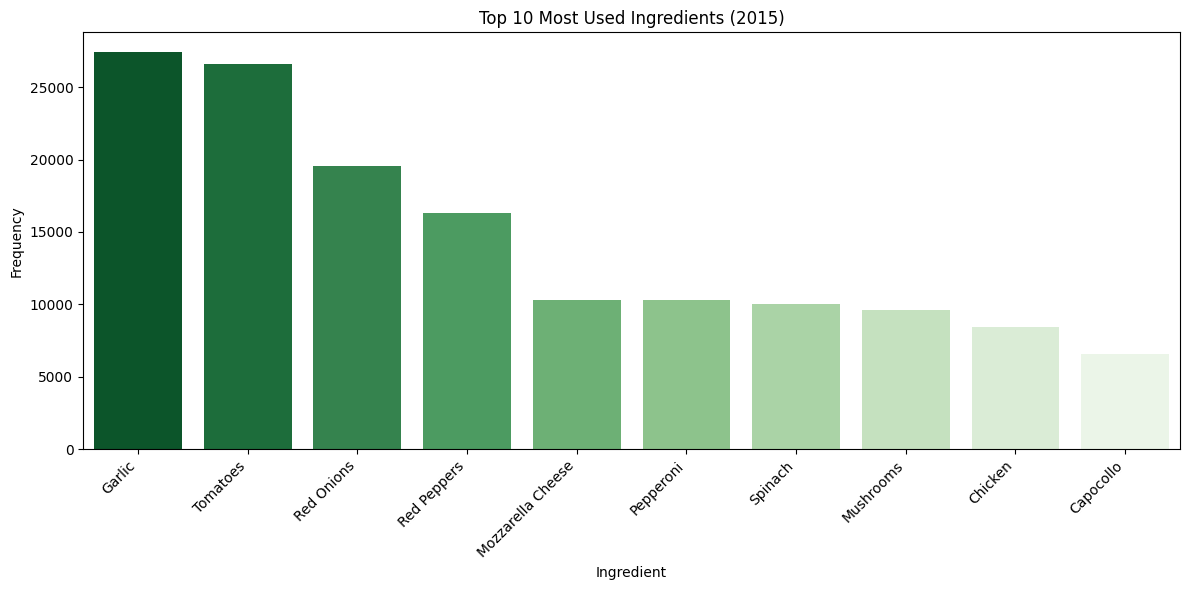

In [23]:
# Extract all ingredients from the 'pizza_ingredients' column
all_ingredients = sales_2015['pizza_ingredients'].str.split(', ').explode()

# Count the frequency of each ingredient
ingredient_counts = all_ingredients.value_counts()

# Display the top 10 most used ingredients
top_10_ingredients = ingredient_counts.head(10)

print("Top 10 Most Used Ingredients (2015):")
print(top_10_ingredients)

# Plotting the top 10 most used ingredients
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_ingredients.index, y=top_10_ingredients.values, palette='Greens_r')
plt.title('Top 10 Most Used Ingredients (2015)')
plt.xlabel('Ingredient')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Summary of Ingredient & Inventory Optimization Findings

**Most Used Ingredients:**
The analysis of ingredient usage revealed the following top 10 most frequently used ingredients in 2015:
1.  Garlic (27,422 uses)
2.  Tomatoes (26,601 uses)
3.  Red Onions (19,547 uses)
4.  Red Peppers (16,284 uses)
5.  Mozzarella Cheese (10,333 uses)
6.  Pepperoni (10,300 uses)
7.  Spinach (10,012 uses)
8.  Mushrooms (9,624 uses)
9.  Chicken (8,443 uses)
10. Capocollo (6,572 uses)

Garlic, Tomatoes, and Red Onions are significantly more frequently used than other ingredients, highlighting their critical role in the pizza menu. This information is vital for inventory management to ensure a consistent supply of these high-demand items.

**Cost vs. Revenue Analysis:**
It is important to note that a direct cost vs. revenue analysis for ingredients could not be performed due to the absence of ingredient cost data in the provided dataset. To conduct this analysis, information regarding the purchase prices and quantities of ingredients used per pizza would be required.

### Cost vs. Revenue Analysis

**Limitation:** The dataset provided does not contain information on the cost of ingredients or pizza production. Therefore, a direct cost vs. revenue analysis per pizza type cannot be performed. To conduct this analysis, we would need additional data on ingredient purchase prices and quantities used per pizza.

---

## 6. Operational Efficiency & Order Fulfillment

Let's examine aspects related to order processing and fulfillment, though with some data limitations.

### Order Processing Time

**Limitation:** The dataset contains `order_date` and `order_time`, which were combined into `order_datetime`, but it does not include timestamps for order fulfillment or delivery. Without a 'fulfillment_time' or similar column, it is not possible to calculate the average time between order placement and fulfillment. To perform this analysis, the dataset would need to be augmented with fulfillment timestamps.

### Delivery vs. Dine-in Sales

**Limitation:** The dataset does not contain any information categorizing orders by service channel (e.g., delivery, dine-in, take-out). Therefore, we cannot compare sales across these different channels with the available data. To perform this analysis, an 'order_type' or similar column indicating the service channel would be required.

---

## 7. Summary Report of Analysis Findings

This report summarizes the key insights derived from the analysis of pizza sales data for the year 2015. The analysis focused on sales performance, product optimization, customer behavior, pricing strategies, ingredient management, and operational efficiency.

### 1. Sales Performance & Revenue Analysis

*   **Total Revenue:** The business generated a total revenue of **$817,860.05** in 2015.
*   **Monthly Trends:** July was the highest revenue month ($72,557.90), while September and October were the lowest. This suggests some seasonal fluctuation.
*   **Daily Trends:** Friday was the peak sales day ($136,073.90), with Thursday and Saturday also showing strong performance. Sundays and Mondays had the lowest revenue.
*   **Hourly Trends:** Peak revenue periods were identified between **11 AM - 1 PM (lunch)** and **5 PM - 7 PM (dinner)**, indicating prime hours for business operations.
*   **Average Order Value (AOV):** The average revenue per order was **$38.31**.

### 2. Product Performance & Menu Optimization

*   **Top 5 Selling Pizzas (by Quantity):** 'The Classic Deluxe Pizza', 'The Barbecue Chicken Pizza', 'The Hawaiian Pizza', 'The Pepperoni Pizza', and 'The Thai Chicken Pizza' were the best sellers.
*   **Bottom 5 Selling Pizzas (by Quantity):** 'The Brie Carre Pizza', 'The Mediterranean Pizza', 'The Calabrese Pizza', 'The Spinach Supreme Pizza', and 'The Soppressata Pizza' were the least popular.
*   **Revenue by Category:** 'Classic' pizzas generated the most revenue, followed by 'Supreme', 'Chicken', and 'Veggie' categories.
*   **Revenue by Size:** 'Large' pizzas contributed the most to revenue, followed by 'Medium' and 'Small'. 'XL' and 'XXL' sizes accounted for a significantly smaller portion of sales.

### 3. Customer & Order Behaviour

*   **Average Quantity per Order:** Customers typically ordered an average of **2.32 pizzas** per transaction.
*   **Most Common Order Time:** **12:00 PM (noon)** was the busiest hour for orders, aligning with the peak hourly revenue findings.
*   **Orders by Day of the Week:** Friday recorded the highest number of orders, consistent with peak revenue days.

### 4. Pricing & Discount Strategy

*   **Price Sensitivity:** The analysis showed higher sales volumes for pizzas priced in the mid-range (approximately $12-$17), with lower volumes at price extremes.
*   **High-Value vs. Low-Value Orders:** Orders with revenue greater than the median ($32.50) were classified as high-value, contributing a substantial **74.27%** of the total revenue.
*   **Seasonal Pricing Effects:** The average price per pizza remained consistent throughout the year. However, opportunities for promotions were identified during low-demand months (Sept, Oct, Feb, Dec) to boost quantity, and strategies for upselling/cross-selling were suggested for high-demand months (Jan, Mar, May, Jul).

### 5. Ingredient & Inventory Optimization

*   **Most Used Ingredients:** 'Garlic', 'Tomatoes', 'Red Onions', 'Red Peppers', and 'Mozzarella Cheese' were the most frequently used ingredients, indicating their critical importance for inventory management.
*   **Cost vs. Revenue Analysis Limitation:** This analysis could not be performed due to the lack of ingredient cost data in the dataset.

### 6. Operational Efficiency & Order Fulfillment

*   **Order Processing Time Limitation:** This analysis could not be performed as the dataset lacked timestamps for order fulfillment.
*   **Delivery vs. Dine-in Sales Limitation:** The dataset did not include information on service channels (e.g., delivery, dine-in), preventing a comparison of sales across these categories.

### Overall Conclusion

The analysis provides a robust foundation for strategic decision-making in various aspects of the pizza business. Key areas for focus include optimizing the menu based on product performance, leveraging peak sales periods through staffing and targeted promotions, and streamlining inventory based on ingredient usage. Addressing the data limitations by collecting information on ingredient costs, fulfillment times, and service channels would enable even deeper and more actionable insights for future analysis.

## 8. Actionable Business Recommendations

Based on the detailed analysis of the 2015 pizza sales data, here are several actionable recommendations to optimize operations, enhance profitability, and improve customer satisfaction:

### 1. Menu Optimization & Product Strategy

*   **Promote Top Sellers:** Actively highlight 'The Classic Deluxe Pizza', 'The Barbecue Chicken Pizza', 'The Hawaiian Pizza', 'The Pepperoni Pizza', and 'The Thai Chicken Pizza' in marketing materials, online menus, and in-store displays. Consider creating bundles around these popular items.
*   **Review Underperforming Pizzas:** Re-evaluate 'The Brie Carre Pizza', 'The Mediterranean Pizza', 'The Calabrese Pizza', 'The Spinach Supreme Pizza', and 'The Soppressata Pizza'. Consider:
    *   **Marketing Boost:** Relaunch with targeted promotions or new descriptions.
    *   **Recipe Adjustment:** Tweak ingredients or presentation.
    *   **Removal:** If efforts are unsuccessful, consider removing them to streamline operations and reduce inventory complexity.
*   **Capitalize on Categories & Sizes:**
    *   Continue to focus on 'Classic' and 'Supreme' pizza categories, as they are major revenue drivers.
    *   Prioritize 'Large' and 'Medium' pizza production and availability, as they contribute most significantly to revenue. 'XL' and 'XXL' are niche and should be managed accordingly.

### 2. Staffing & Operational Efficiency

*   **Optimize Staffing for Peak Periods:** Schedule additional staff during peak hours (11 AM-1 PM and 5 PM-7 PM) and peak days (Friday, Thursday, and Saturday) to handle higher order volumes, reduce wait times, and ensure smooth operations.
*   **Adjust Staffing for Low Periods:** Consider reduced staffing during low revenue days (Sunday, Monday) and hours outside of peak times to manage labor costs effectively.

### 3. Pricing & Promotion Strategy

*   **Targeted Promotions for Low-Demand Months:** Implement specific promotions during September, October, February, and December to stimulate sales:
    *   **Bundle Deals:** Offer family-sized bundles or meal deals.
    *   **Loyalty Incentives:** Provide double points or exclusive discounts for loyalty program members.
    *   **Seasonal Specials:** Introduce limited-time, festive pizzas to create excitement.
*   **Upselling & Cross-selling in High-Demand Months:** During January, March, May, and July, focus on increasing Average Order Value (AOV) by:
    *   Training staff to upsell larger sizes or premium toppings.
    *   Promoting add-ons like drinks, desserts, or sides.
*   **Leverage High-Value Orders:** Since high-value orders contribute a significant portion of revenue, consider loyalty programs or exclusive offers specifically tailored to encourage repeat purchases from these customers.

### 4. Inventory Management

*   **Prioritize Key Ingredient Stock:** Ensure a consistent and ample supply of 'Garlic', 'Tomatoes', 'Red Onions', 'Red Peppers', and 'Mozzarella Cheese', as these are the most frequently used ingredients. Establish reliable suppliers and optimize ordering cycles for these items.
*   **Supplier Negotiations:** Given the high volume of top ingredients, explore opportunities for bulk purchasing discounts with suppliers.

### 5. Data Enhancement for Future Analysis

*   **Collect Ingredient Cost Data:** Implement a system to track the cost of ingredients per pizza to enable comprehensive cost-benefit analysis and better menu pricing decisions.
*   **Record Fulfillment Times:** Capture timestamps for order fulfillment or delivery to analyze processing efficiency and identify bottlenecks.
*   **Categorize Order Types:** Introduce a field to categorize orders (e.g., delivery, dine-in, take-out) to understand sales distribution across different service channels and inform marketing and operational strategies for each.